### Cell 1: Dependencies and GPU Setup
We use EfficientNetB0 for its sensitivity to fine-grained features.

In [1]:
import os
import tarfile
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import urllib.request

# Check for GPU - Cloud environments need this to handle high-res patches
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Check your Cloud Runtime settings.')
else:
  print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


### Cell 2: Download and Extract Dataset
Using the FantasyID dataset from Zenodo.

In [2]:
dataset_url = "https://zenodo.org/records/17063366/files/FantasyID.tgz?download=1"
archive_path = "FantasyID.tgz"
dataset_dir = "FantasyID_Dataset"

if not os.path.exists(archive_path):
    print("Downloading FantasyID dataset...")
    urllib.request.urlretrieve(dataset_url, archive_path)
    print("Download complete.")
else:
    print("Archive already downloaded.")

if not os.path.exists(dataset_dir):
    print("Extracting dataset...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=dataset_dir)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

Download complete.
Extracting dataset...


/tmp/ipykernel_2629/2633879303.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=dataset_dir)


Extraction complete.


### Cell 3: Load Data and Visualize Samples
We load the images dynamically using standard Keras data loaders.

Found 3292 files belonging to 1 classes.
Using 2634 files for training.
Found 3292 files belonging to 1 classes.
Using 658 files for validation.
Detected Classes: ['FantasyID']


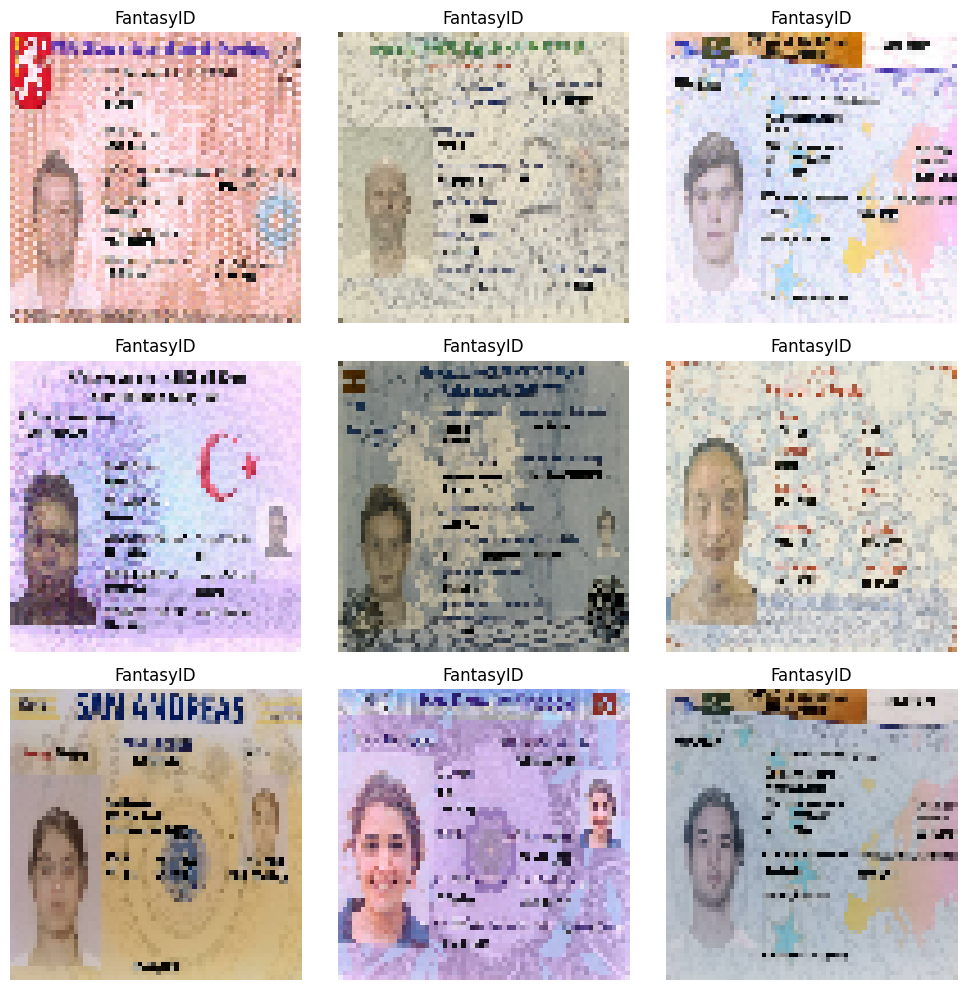

In [3]:
batch_size = 32
img_height = 64
img_width = 64

# Assuming extracted files are directly in dataset_dir or a subfolder
# Change this path if the tarball extracts to a nested folder (e.g., 'FantasyID_Dataset/FantasyID')
base_dir = dataset_dir 

train_ds = tf.keras.utils.image_dataset_from_directory(
  base_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  base_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

class_names = train_ds.class_names
print("Detected Classes:", class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(min(9, len(images))):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

### Cell 4: Forensic Augmentation & Model Architecture
We define augmentation specifically mimicking camera noise.

In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.GaussianNoise(0.05), 
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

def build_forensic_model(input_shape=(64, 64, 3)):
    base_model = applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = True
    for layer in base_model.layers[40:]:
        layer.trainable = False

    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        base_model,
        layers.GlobalMaxPooling2D(), 
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        # Automatically handle binary or multi-class depending on our dataset labels
        layers.Dense(1 if len(class_names) == 2 else len(class_names), 
                     activation='sigmoid' if len(class_names) == 2 else 'softmax')
    ])

    loss_fn = 'binary_crossentropy' if len(class_names) == 2 else 'sparse_categorical_crossentropy'
    
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss=loss_fn,
        metrics=['accuracy']
    )
    return model

model = build_forensic_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 2, 2, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 1280)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 342,413 (1.31 MB)

 Non-trainable params: 4,036,375 (15.40 MB)

### Cell 5: Training
Train the model with early stopping.

In [5]:
EPOCHS = 15

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

model.save("forgery_detector_v1.h5")
print("Model saved for cloud deployment.")

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


83/83 ━━━━━━━━━━━━━━━━━━━━ 78s 693ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/15
19/83 ━━━━━━━━━━━━━━━━━━━━ 30s 477ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00

KeyboardInterrupt: 

### Cell 6: Visualizations (Training Curves & Confusion Matrix)

In [ ]:
# Plot Training Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Confusion Matrix
print("Generating Confusion Matrix...")
y_true = []
y_pred_probs = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)

# Handle Binary vs Multi-class predictions
if len(class_names) == 2:
    y_pred = (np.array(y_pred_probs) > 0.5).astype(int).flatten()
else:
    y_pred = np.argmax(np.array(y_pred_probs), axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names, zero_division=0))